In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("netflix_dataset(in).csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["director"] = df["director"].fillna("Unknown Director")
df["cast"] = df["cast"].fillna("Not Available")
df["country"] = df["country"].fillna("Unknown Country")

df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

In [10]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [11]:
df.to_csv("cleaned_netflix_data.csv", index=False)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(8807, 12)

In [14]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [15]:
df["rating"].value_counts()

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [16]:
df["country"].value_counts().head(10)

country
United States      2818
India               972
Unknown Country     831
United Kingdom      419
Japan               245
South Korea         199
Canada              181
Spain               145
France              124
Mexico              110
Name: count, dtype: int64

In [17]:
df["release_year"].describe()

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

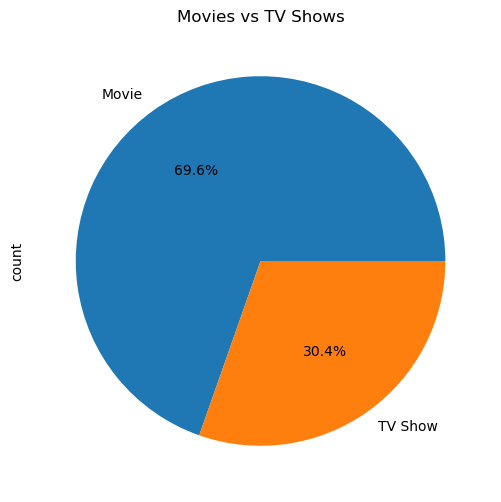

In [18]:
import matplotlib.pyplot as plt

df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Movies vs TV Shows")
plt.show()

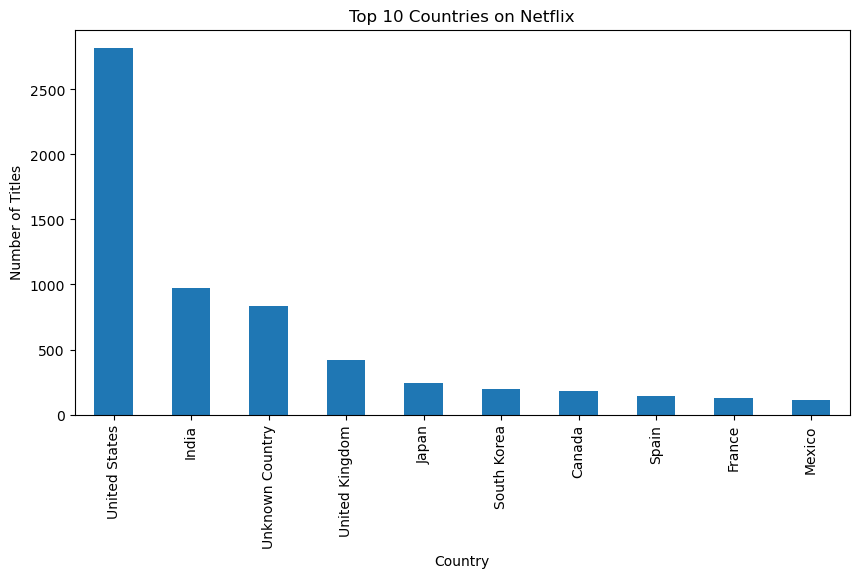

In [19]:
import matplotlib.pyplot as plt

df["country"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()

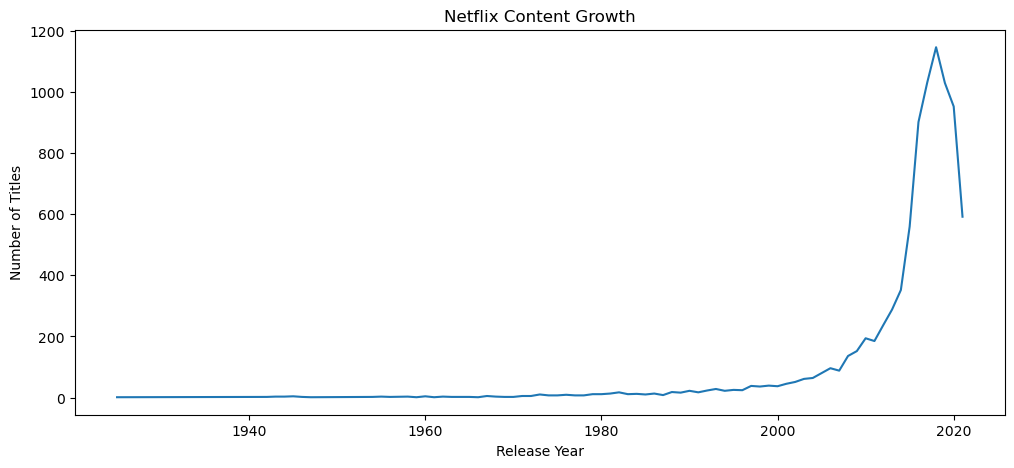

In [20]:
df["release_year"].value_counts().sort_index().plot(
    figsize=(12,5)
)

plt.title("Netflix Content Growth")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

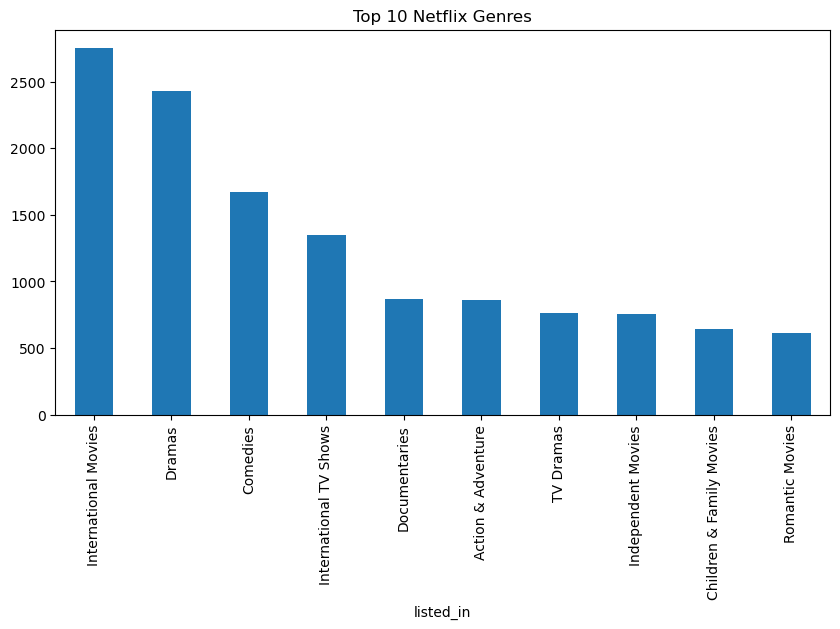

In [21]:
genres = df["listed_in"].str.split(",").explode()

genres = genres.str.strip()

genres.value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Netflix Genres")

plt.show()

In [23]:
df[["date_added","year_added","month_added"]].head()

,date_added,year_added,month_added
0,2021-09-25,2021,September
1,2021-09-24,2021,September
2,2021-09-24,2021,September
3,2021-09-24,2021,September
4,2021-09-24,2021,September


In [24]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

In [25]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

In [28]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added'],
      dtype='object')

In [31]:
pip install textblob

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
from textblob import TextBlob

In [2]:
from textblob import TextBlob

print("TextBlob Working!")

TextBlob Working!


In [10]:

import pandas as pd

df = pd.read_csv("netflix_dataset(in).csv")

In [11]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [12]:
from textblob import TextBlob

df["sentiment"] = df["description"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

In [13]:
df[["title","sentiment"]].head()

,title,sentiment
0,Dick Johnson Is Dead,0.333333
1,Blood & Water,0.000000
2,Ganglands,-0.050000
3,Jailbirds New Orleans,-0.030505
4,Kota Factory,0.000000


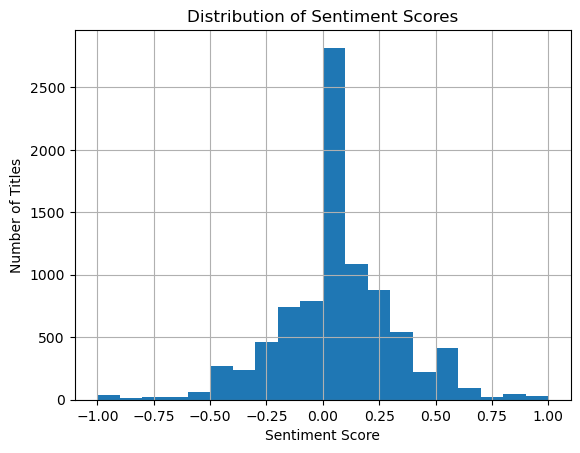

In [14]:
import matplotlib.pyplot as plt

df["sentiment"].hist(bins=20)

plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Number of Titles")
plt.show()

In [15]:
df[["title","sentiment"]].sort_values(
    by="sentiment",
    ascending=False
).head(10)

,title,sentiment
3628,Léa & I,1.0
1091,The Way of the Househusband,1.0
6145,American Masters: Ted Williams,1.0
8641,Turbo,1.0
840,Baggio: The Divine Ponytail,1.0
2688,Moms at War,1.0
3386,Dancing with the Birds,1.0
7658,Once Upon a Time in London,1.0
3841,Wine Country,1.0
1508,Timmy Time,1.0


In [16]:
df.to_csv("netflix_enhanced.csv", index=False)

In [17]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'sentiment'],
      dtype='object')

In [4]:
import os
print(os.listdir())

['.anaconda', '.cache', '.conda', '.continuum', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', '3D Objects', 'AppData', 'Application Data', 'cleaned_customer_data.csv', 'cleaned_netflix_data.csv', 'Contacts', 'Cookies', 'customer_shopping_behavior.csv', 'Customer_Shopping_Behaviour.ipynb', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Music', 'My Documents', 'Netflix _buzz_score.ipynb', 'netflix_dataset(in).csv', 'netflix_enhanced.csv', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{b7a9ec14-dd88-11f0-b169-909d3a112126}.TM.blf', 'NTUSER.DAT{b7a9ec14-dd88-11f0-b169-909d3a112126}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{b7a9ec14-dd88-11f0-b169-909d3a112126}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'PyCharmMiscProject', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Videos']


In [5]:
import os
for file in os.listdir():
    print(file)

.anaconda
.cache
.conda
.continuum
.gitconfig
.idlerc
.ipynb_checkpoints
.ipython
.jupyter
.matplotlib
.vscode
3D Objects
AppData
Application Data
cleaned_customer_data.csv
cleaned_netflix_data.csv
Contacts
Cookies
customer_shopping_behavior.csv
Customer_Shopping_Behaviour.ipynb
Documents
Downloads
Favorites
IntelGraphicsProfiles
Links
Local Settings
Music
My Documents
Netflix _buzz_score.ipynb
netflix_dataset(in).csv
netflix_enhanced.csv
NetHood
NTUSER.DAT
ntuser.dat.LOG1
ntuser.dat.LOG2
NTUSER.DAT{b7a9ec14-dd88-11f0-b169-909d3a112126}.TM.blf
NTUSER.DAT{b7a9ec14-dd88-11f0-b169-909d3a112126}.TMContainer00000000000000000001.regtrans-ms
NTUSER.DAT{b7a9ec14-dd88-11f0-b169-909d3a112126}.TMContainer00000000000000000002.regtrans-ms
ntuser.ini
OneDrive
PrintHood
PyCharmMiscProject
Recent
Saved Games
Searches
SendTo
Start Menu
Templates
Videos


In [6]:
import pandas as pd

df = pd.read_csv('cleaned_netflix_data.csv')

In [7]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown Country,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown Director,Not Available,Unknown Country,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown Director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
df['director'] = df['director'].fillna('Unknown Director')
df['cast'] = df['cast'].fillna('Unknown Cast')
df['country'] = df['country'].fillna('Unknown Country')

In [10]:
print(df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [11]:
pip install textblob

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [12]:
from textblob import TextBlob

df['sentiment'] = df['description'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

In [13]:
def sentiment_category(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment'].apply(sentiment_category)

In [14]:
df[['title', 'sentiment', 'sentiment_category']].head()

,title,sentiment,sentiment_category
0,Dick Johnson Is Dead,0.333333,Positive
1,Blood & Water,0.000000,Neutral
2,Ganglands,-0.050000,Neutral
3,Jailbirds New Orleans,-0.030505,Neutral
4,Kota Factory,0.000000,Neutral


In [15]:
print(df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'sentiment', 'sentiment_category']


In [16]:
df.to_csv('netflix_enhanced.csv', index=False)

In [2]:
import pandas as pd

In [4]:
df = pd.read_csv('cleaned_netflix_data.csv')

In [5]:
print(df.head())

  show_id     type                  title          director  \
0      s1    Movie   Dick Johnson Is Dead   Kirsten Johnson   
1      s2  TV Show          Blood & Water  Unknown Director   
2      s3  TV Show              Ganglands   Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans  Unknown Director   
4      s5  TV Show           Kota Factory  Unknown Director   

                                                cast          country  \
0                                      Not Available    United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...     South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...  Unknown Country   
3                                      Not Available  Unknown Country   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...            India   

  date_added  release_year rating   duration  \
0  25-Sep-21          2020  PG-13     90 min   
1  24-Sep-21          2021  TV-MA  2 Seasons   
2  24-Sep-21          2021  TV-MA   1 

In [6]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [8]:
print("Director blanks:", (df['director'].str.strip() == "").sum())
print("Cast blanks:", (df['cast'].str.strip() == "").sum())
print("Country blanks:", (df['country'].str.strip() == "").sum())

Director blanks: 0
Cast blanks: 0
Country blanks: 0


In [9]:
df['director'] = df['director'].replace('', 'Unknown Director')
df['cast'] = df['cast'].replace('', 'Unknown Cast')
df['country'] = df['country'].replace('', 'Unknown Country')

In [10]:
df['director'] = df['director'].replace(r'^\s*$', 'Unknown Director', regex=True)
df['cast'] = df['cast'].replace(r'^\s*$', 'Unknown Cast', regex=True)
df['country'] = df['country'].replace(r'^\s*$', 'Unknown Country', regex=True)

In [11]:
df.head(20)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown Country,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown Director,Not Available,Unknown Country,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown Director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown Country,24-Sep-21,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown Country,24-Sep-21,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",24-Sep-21,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,24-Sep-21,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,24-Sep-21,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [12]:
df.to_csv('netflix_cleaned_final.csv', index=False)

In [13]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [14]:
print(df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [15]:
from textblob import TextBlob

# Sentiment score
df['sentiment'] = df['description'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

# Sentiment category
def sentiment_category(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment'].apply(sentiment_category)

In [16]:
df.to_csv('netflix_dashboard_ready.csv', index=False)

In [17]:
print(df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'sentiment', 'sentiment_category']


In [18]:
df.head(20)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,sentiment,sentiment_category
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",0.333333,Positive
1,s2,TV Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",0.000000,Neutral
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown Country,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,-0.050000,Neutral
3,s4,TV Show,Jailbirds New Orleans,Unknown Director,Not Available,Unknown Country,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",-0.030505,Neutral
4,s5,TV Show,Kota Factory,Unknown Director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,0.000000,Neutral
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown Country,24-Sep-21,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,0.000000,Neutral
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown Country,24-Sep-21,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,0.000000,Neutral
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",24-Sep-21,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",-0.083333,Neutral
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,24-Sep-21,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,0.612500,Positive
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,24-Sep-21,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,0.000000,Neutral


In [19]:
df['main_genre'] = df['listed_in'].str.split(',').str[0].str.strip()

In [20]:
df[['listed_in', 'main_genre']].head()

,listed_in,main_genre
0,Documentaries,Documentaries
1,"International TV Shows, TV Dramas, TV Mysteries",International TV Shows
2,"Crime TV Shows, International TV Shows, TV Act...",Crime TV Shows
3,"Docuseries, Reality TV",Docuseries
4,"International TV Shows, Romantic TV Shows, TV ...",International TV Shows


In [21]:
df.head(20)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,sentiment,sentiment_category,main_genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",0.333333,Positive,Documentaries
1,s2,TV Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",0.000000,Neutral,International TV Shows
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown Country,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,-0.050000,Neutral,Crime TV Shows
3,s4,TV Show,Jailbirds New Orleans,Unknown Director,Not Available,Unknown Country,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",-0.030505,Neutral,Docuseries
4,s5,TV Show,Kota Factory,Unknown Director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,0.000000,Neutral,International TV Shows
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown Country,24-Sep-21,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,0.000000,Neutral,TV Dramas
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown Country,24-Sep-21,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,0.000000,Neutral,Children & Family Movies
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",24-Sep-21,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",-0.083333,Neutral,Dramas
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,24-Sep-21,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,0.612500,Positive,British TV Shows
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,24-Sep-21,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,0.000000,Neutral,Comedies


In [22]:
df.to_csv('netflix_dashboard_ready.csv', index=False)